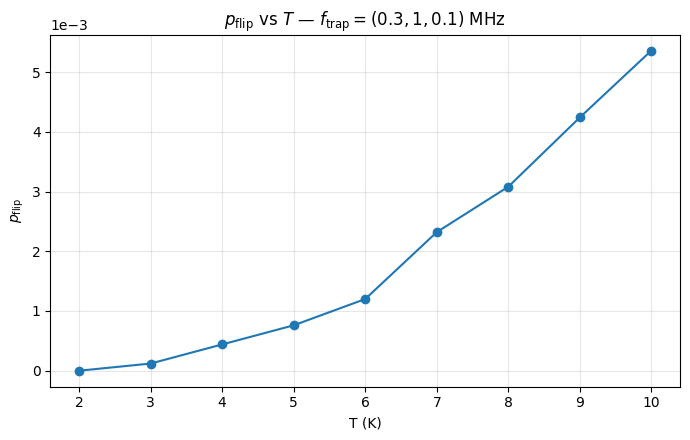

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# === 省频 (axial, radial, radial) MHz ===
trap_freq = (0.3, 1, 0.1)  # MHz

# === 温度 T (K) ===
T_values = np.arange(2, 11, dtype=float)  # 2, 3, ..., 10 K

# === p_flip 数据 ===
# TODO: 填入每个温度对应的 p_flip 值
p_flip = np.array([
   0,  # T = 2 K
    3,  # T = 3 K
    11,  # T = 4 K
    19,  # T = 5 K
    30,  # T = 6 K
    58,  # T = 7 K
    77,  # T = 8 K
    106,  # T = 9 K
    134,  # T = 10 K
])/25000

# === 绘图 ===
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(T_values, p_flip, 'o-', color='tab:blue', markersize=6, linewidth=1.5)

ax.set_xlabel('T (K)')
ax.set_ylabel(r'$p_{\mathrm{flip}}$')
ax.set_title(
    rf'$p_{{\mathrm{{flip}}}}$ vs $T$ — '
    rf'$f_{{\mathrm{{trap}}}}=({trap_freq[0]}, {trap_freq[1]}, {trap_freq[2]})$ MHz'
)
ax.set_xticks(T_values)
ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

fig.tight_layout()
plt.show()

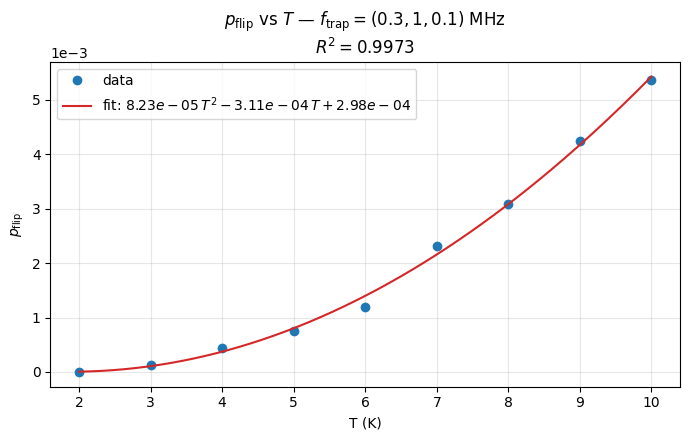

拟合结果: p_flip = 8.2338e-05 * T^2 + (-3.1072e-04) * T + (2.9790e-04)
R² = 0.997269


In [3]:
# === 二次多项式拟合: p_flip = a*T^2 + b*T + c ===
coeffs = np.polyfit(T_values, p_flip, 2)
a, b, c = coeffs
p_fit = np.polyval(coeffs, T_values)

# R^2
ss_res = np.sum((p_flip - p_fit) ** 2)
ss_tot = np.sum((p_flip - np.mean(p_flip)) ** 2)
r_squared = 1 - ss_res / ss_tot

# === 绘图 ===
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(T_values, p_flip, 'o', color='tab:blue', markersize=6, label='data')
T_fine = np.linspace(T_values[0], T_values[-1], 200)
ax.plot(T_fine, np.polyval(coeffs, T_fine), '-', color='tab:red', linewidth=1.5,
        label=rf'fit: ${a:.2e}\,T^2 {b:+.2e}\,T {c:+.2e}$')

ax.set_xlabel('T (K)')
ax.set_ylabel(r'$p_{\mathrm{flip}}$')
ax.set_title(
    rf'$p_{{\mathrm{{flip}}}}$ vs $T$ — '
    rf'$f_{{\mathrm{{trap}}}}=({trap_freq[0]}, {trap_freq[1]}, {trap_freq[2]})$ MHz'
    f'\n'
    rf'$R^2 = {r_squared:.4f}$'
)
ax.set_xticks(T_values.astype(int))
ax.legend()
ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

fig.tight_layout()
plt.show()

print(f'拟合结果: p_flip = {a:.4e} * T^2 + ({b:.4e}) * T + ({c:.4e})')
print(f'R² = {r_squared:.6f}')